# DeepPCB – EDA

1. Kiểm tra cấu trúc dữ liệu
2. Kiểm tra ảnh trùng lặp
3. Phân bố lớp và số lượng box
4. Thống kê pixel và ảnh ngoại lai
5. Xem xét size ảnh

In [36]:
import hashlib
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from PIL import Image

try:
    from IPython.display import display
except ImportError:  # chạy ngoài Jupyter
    display = print

# ---- Cấu hình ----
RANDOM_SEED = 42
DATA_ROOT = Path(os.environ.get("PCB_DATA_ROOT", Path.cwd() / "Data" / "raw_data")).expanduser()
OUT_DIR = Path("outputs") / "eda"
SPLITS = ("train", "valid", "test")
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}
CLASS_ID_BASE = 1          # DeepPCB: class ID 1-6 (0 là background)
SMALL_AREA = 32 * 32       # box nhỏ: diện tích < 32x32 px

rng = np.random.default_rng(RANDOM_SEED)
OUT_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)


def display_path(path):
    try:
        return str(Path(path).resolve().relative_to(Path.cwd()))
    except ValueError:
        return str(path)


ROOT = next((c for c in (DATA_ROOT, DATA_ROOT / "DeepPCB") if (c / "Class.txt").is_file()), None)
if ROOT is None:
    raise FileNotFoundError(f"Không thấy Class.txt trong {DATA_ROOT} hoặc {DATA_ROOT / 'DeepPCB'}")

CLASS_NAMES = [
    n.strip(" '\"")
    for n in (ROOT / "Class.txt").read_text(encoding="utf-8").strip().split(",")
    if n.strip(" '\"")
]
assert len(CLASS_NAMES) == 6, f"Kỳ vọng 6 lớp, đọc được: {CLASS_NAMES}"
print("Data root:", display_path(ROOT))
print("Class ID", {i + CLASS_ID_BASE: n for i, n in enumerate(CLASS_NAMES)})

Data root: Data\raw_data
Class ID {1: 'open', 2: 'short', 3: 'mousebite', 4: 'spur', 5: 'copper', 6: 'pin-hole'}


- Dataset là tập hợp các ảnh defect PCB đã được chia sẵn thành các split train/valid/test

- Trong mỗi split chứa tập images chứa hình ảnh và tập labels chứa nhãn của các lỗi trên hình

- Class.txt là file chứa phân loại lỗi

- Các loại defect gồm 6 loại: Open, Short, Mousebite, Spur, Copper, Pinhole

## 1. Kiểm tra cấu trúc dữ liệu

Kiểm tra ảnh và nhãn có khớp nhau không

Kích thước ảnh có đồng nhất không

Nhãn có hợp lệ không

In [35]:
image_rows, box_rows, problems = [], [], []
label_files = {}


def add_problem(split, file, issue, detail=""):
    problems.append({"split": split, "file": file, "issue": issue, "detail": detail})


for split in SPLITS:
    img_dir, lbl_dir = ROOT / split / "images", ROOT / split / "labels"
    if not (img_dir.is_dir() and lbl_dir.is_dir()):
        raise FileNotFoundError(f"Thiếu images/labels trong {display_path(ROOT / split)}")

    image_paths = sorted(p for p in img_dir.iterdir() if p.suffix.lower() in IMAGE_SUFFIXES)
    stems = {p.stem for p in image_paths}
    label_paths = list(lbl_dir.glob("*.txt"))
    label_files[split] = len(label_paths)
    for lp in label_paths:
        if lp.stem not in stems:
            add_problem(split, lp.name, "nhãn không có ảnh")

    for ip in image_paths:
        try:
            with Image.open(ip) as im:
                im.load()
                width, height = im.size
                mode = im.mode
        except Exception as error:
            add_problem(split, ip.name, "ảnh không đọc được", str(error))
            continue

        n_boxes = 0
        lp = lbl_dir / f"{ip.stem}.txt"
        if not lp.is_file():
            add_problem(split, ip.name, "ảnh không có file nhãn")
        else:
            for line_no, line in enumerate(lp.read_text(encoding="utf-8").splitlines(), start=1):
                if not line.strip():
                    continue
                parts = line.split()
                where = f"{lp.name}:{line_no}"
                if len(parts) != 5:
                    add_problem(split, where, "sai số trường", line)
                    continue
                try:
                    x1, y1, x2, y2, cid = map(int, parts)
                except ValueError:
                    add_problem(split, where, "giá trị không phải số nguyên", line)
                    continue
                cidx = cid - CLASS_ID_BASE
                if not 0 <= cidx < len(CLASS_NAMES):
                    add_problem(split, where, "class ID lạ", line)
                elif x2 <= x1 or y2 <= y1:
                    add_problem(split, where, "box suy biến", line)
                elif x1 < 0 or y1 < 0 or x2 > width or y2 > height:
                    add_problem(split, where, "box ngoài ảnh", line)
                else:
                    n_boxes += 1
                    box_rows.append({
                        "split": split, "image_name": ip.name, "image_key": f"{split}/{ip.name}",
                        "x1": x1, "y1": y1, "x2": x2, "y2": y2,
                        "w": x2 - x1, "h": y2 - y1, "area": (x2 - x1) * (y2 - y1),
                        "class_id": cid, "class_idx": cidx, "class_name": CLASS_NAMES[cidx],
                    })

        image_rows.append({
            "split": split, "image_name": ip.name, "image_key": f"{split}/{ip.name}",
            "image_path": ip, "width": width, "height": height, "mode": mode, "n_boxes": n_boxes,
        })

manifest = pd.DataFrame(image_rows)
annotations = pd.DataFrame(box_rows)
problems_df = pd.DataFrame(problems, columns=["split", "file", "issue", "detail"])
assert not manifest.empty and not annotations.empty, "Không đọc được ảnh hoặc box nào"

inventory = manifest.groupby("split").agg(
    images=("image_name", "size"),
    boxes=("n_boxes", "sum"),
    images_no_box=("n_boxes", lambda s: int((s == 0).sum())),
).reindex(SPLITS)
inventory.insert(1, "label_files", pd.Series(label_files))
display(inventory)

print("Kích thước ảnh (width x height):")
display(manifest.groupby(["width", "height"]).size().rename("images").to_frame())
print("Mode ảnh gốc:")
display(manifest["mode"].value_counts().rename("images").to_frame())

dup_names = manifest.groupby("image_name")["split"].nunique()
print(f"Tên file trùng giữa các split: {int((dup_names > 1).sum())}")
print(f"Vấn đề cấu trúc/nhãn: {len(problems_df)}")
if len(problems_df):
    display(problems_df.groupby("issue").size().rename("count").to_frame())
    display(problems_df.head(20))

,images,label_files,boxes,images_no_box
split,,,,
train,1200,1200,8024,0
valid,150,150,1005,0
test,150,150,984,0


Kích thước ảnh (width x height):


,,images
width,height,
640,640,1500


Mode ảnh gốc:


,images
mode,
L,1462
RGB,38


Tên file trùng giữa các split: 0
Vấn đề cấu trúc/nhãn: 0


- Bộ dữ liệu có 1.500 ảnh (640×640, một kích thước duy nhất) và 10.013 box
- Số lượng ảnh trên test/valid/test lần lượt là 1200/150/150. Tỉ lệ chia ảnh vào train/val/test đã ổn
- Không có lỗi cấu trúc hay lỗi nhãn, không có ảnh thiếu nhãn
- Không có ảnh có tên trùng nhau giữa các split
- Trong toàn bộ dataset, có xuất hiện 38 ảnh mode RGB, còn lại là ảnh mode L-> kiểm tra lại ảnh để xem mode ảnh xác định đúng chưa

## 2. Kiểm tra ảnh trùng lặp
Dùng SHA-256 để tìm xem có ảnh trùng trên các split không

Hash trên pixel kiểm tra xem có ảnh nào nội dung giống nhau nhưng bản sao được lưu lại với định dạng/mode khác. Với mỗi nhóm trùng, so sánh nhãn xem các bản sao có gán nhãn giống nhau không.

In [18]:
byte_hash, pixel_hash = [], []
for row in manifest.itertuples():
    byte_hash.append(hashlib.sha256(row.image_path.read_bytes()).hexdigest())
    with Image.open(row.image_path) as im:
        rgb = np.asarray(im.convert("RGB"))
    pixel_hash.append(hashlib.sha256(rgb.tobytes() + str(rgb.shape).encode()).hexdigest())
manifest["sha256"] = byte_hash
manifest["pixel_hash"] = pixel_hash

label_sig = {
    key: tuple(sorted(zip(g["x1"], g["y1"], g["x2"], g["y2"], g["class_id"])))
    for key, g in annotations.groupby("image_key")
}

dup_rows = []
for _, g in manifest.groupby("pixel_hash"):
    if len(g) < 2:
        continue
    keys = list(g["image_key"])
    dup_rows.append({
        "images": ", ".join(keys),
        "n_images": len(g),
        "splits": ", ".join(sorted(set(g["split"]))),
        "cross_split": g["split"].nunique() > 1,
        "byte_identical": g["sha256"].nunique() == 1,
        "same_labels": len({label_sig.get(k, ()) for k in keys}) == 1,
    })
dup_table = pd.DataFrame(
    dup_rows, columns=["images", "n_images", "splits", "cross_split", "byte_identical", "same_labels"]
)

n_dup_groups = len(dup_table)
n_dup_extra = int((dup_table["n_images"] - 1).sum()) if n_dup_groups else 0
n_dup_cross = int(dup_table["cross_split"].sum()) if n_dup_groups else 0
n_dup_byte = int(dup_table["byte_identical"].sum()) if n_dup_groups else 0
n_dup_conflict = int((~dup_table["same_labels"]).sum()) if n_dup_groups else 0
n_byte_groups = int((manifest.groupby("sha256")["image_key"].transform("size") > 1).sum())

print(f"Ảnh trùng byte (SHA-256): {n_byte_groups} ảnh nằm trong nhóm trùng")
print(f"Nhóm trùng pixel: {n_dup_groups} nhóm, {n_dup_extra} ảnh thừa | "
      f"nằm ở nhiều split: {n_dup_cross} | trùng cả byte: {n_dup_byte} | "
      f"nhãn khác nhau giữa các bản sao: {n_dup_conflict}")

SPLIT_PRIORITY = {name: i for i, name in enumerate(SPLITS)}
dup_remove_keys = []
if n_dup_groups:
    with pd.option_context("display.max_colwidth", None):
        display(dup_table)
    for _, g in manifest.groupby("pixel_hash"):
        if len(g) < 2:
            continue
        ordered = g.assign(_p=g["split"].map(SPLIT_PRIORITY)).sort_values(["_p", "image_name"])
        dup_remove_keys.extend(ordered["image_key"].iloc[1:])  # giữ bản đầu (ưu tiên train)
    pd.DataFrame({"image_key": dup_remove_keys}).to_csv(OUT_DIR / "duplicates_to_remove.csv", index=False)
    print(f"Đề xuất loại {len(dup_remove_keys)} ảnh -> outputs/eda/duplicates_to_remove.csv")

    shown = dup_table.head(3)
    fig, axes = plt.subplots(len(shown), 2, figsize=(8, 4 * len(shown)), squeeze=False)
    for r, (_, d) in enumerate(shown.iterrows()):
        for c, key in enumerate(d["images"].split(", ")[:2]):
            path = manifest.loc[manifest["image_key"] == key, "image_path"].iloc[0]
            with Image.open(path) as im:
                axes[r, c].imshow(im.convert("L"), cmap="gray", vmin=0, vmax=255)
            axes[r, c].set_title(key, fontsize=9)
            axes[r, c].axis("off")
    fig.suptitle("Ví dụ các nhóm ảnh trùng", y=1.0)
    fig.tight_layout()
    plt.show()
else:
    print("Không có ảnh trùng lặp.")

Ảnh trùng byte (SHA-256): 0 ảnh nằm trong nhóm trùng
Nhóm trùng pixel: 0 nhóm, 0 ảnh thừa | nằm ở nhiều split: 0 | trùng cả byte: 0 | nhãn khác nhau giữa các bản sao: 0
Không có ảnh trùng lặp.


- Không có ảnh trùng lặp giữa các split -> không có leakage

## 3. Phân bố lớp và kích thước box
Check input size, box size, stride nhỏ nhất của head

Dataset có xuất hiện sự mất cân bằng giữa 6 nhóm lỗi không.

In [40]:
SPLIT_COL = "split"
annotations["aspect"] = annotations["w"] / annotations["h"]
annotations["side"] = np.sqrt(annotations["area"])
annotations["is_small"] = annotations["area"] < SMALL_AREA

# --- Lớp x split ---
box_by_class = (annotations.groupby([SPLIT_COL, "class_name"]).size().unstack(0)
                .reindex(index=CLASS_NAMES, columns=SPLITS).fillna(0).astype(int))
box_by_class["total"] = box_by_class.sum(axis=1)
box_by_class["% total"] = (100 * box_by_class["total"] / box_by_class["total"].sum()).round(1)
img_by_class = (annotations.groupby([SPLIT_COL, "class_name"])["image_key"].nunique().unstack(0)
                .reindex(index=CLASS_NAMES, columns=SPLITS).fillna(0).astype(int))
print("Số box theo lớp x split:")
display(box_by_class)
print("Số ảnh chứa lớp theo lớp x split:")
display(img_by_class)

class_totals = box_by_class["total"]
imbalance_ratio = class_totals.max() / class_totals.min()
min_eval_class_boxes = int(box_by_class[["valid", "test"]].min().min())
print(f"Tỷ lệ mất cân bằng (max/min box): {imbalance_ratio:.2f} | "
      f"số box ít nhất của một lớp trong valid/test: {min_eval_class_boxes}")


print("Số box/ảnh theo split:")
display(manifest.groupby(SPLIT_COL)["n_boxes"].describe().reindex(SPLITS).round(2))

Số box theo lớp x split:


split,train,valid,test,total,% total
class_name,,,,,
open,1562,189,191,1942,19.4
short,1169,167,170,1506,15.0
mousebite,1582,189,194,1965,19.6
spur,1307,165,153,1625,16.2
copper,1186,148,140,1474,14.7
pin-hole,1218,147,136,1501,15.0


Số ảnh chứa lớp theo lớp x split:


split,train,valid,test
class_name,,,
open,1072,138,134
short,870,117,114
mousebite,1014,126,129
spur,952,119,113
copper,997,125,119
pin-hole,1065,126,124


Tỷ lệ mất cân bằng (max/min box): 1.33 | số box ít nhất của một lớp trong valid/test: 136
Số box/ảnh theo split:


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
train,1200.0,6.69,1.81,1.0,5.0,7.0,8.0,15.0
valid,150.0,6.70,1.85,3.0,5.0,7.0,8.0,13.0
test,150.0,6.56,1.81,1.0,5.0,7.0,8.0,12.0


- Phân bố lỗi khá cân bằng trên cả 3 split
- Tỷ lệ mất cân bằng chỉ 1,33x, ít nhất là copper với 1.474 box, nhiều nhất là mousebite với 1.965 box
- Số box trung bình mỗi ảnh là 6,6 box/ ảnh
- Lớp ít box nhất trong valid/test vẫn có 136 box, nên AP theo lớp đủ ổn định và không cần class weighting.

## 4. Thống kê pixel và ảnh ngoại lai

Check lại mode ảnh là xám thật hay RGB? Có gần nhị phân không? Có ảnh nào bất thường về độ sáng/tương phản không?

Phát hiện ảnh ngoại lai bằng IQR

Mode gốc: {'L': 1462, 'RGB': 38} | ảnh có kênh màu thật sự khác nhau: 1
Mean / std độ sáng theo ảnh (thang 0-255):


mean                                std                           extreme_frac                     
          mean     min   median      max     mean     min   median      max         mean    min median    max
split                                                                                                        
train  166.161  43.332  173.098  254.915  108.316   4.552  115.633  127.400        0.984  0.912  0.987  1.000
valid  162.537  46.184  172.862  250.858  109.078  32.064  114.296  127.270        0.980  0.857  0.985  0.998
test   166.152  36.678  172.134  254.746  106.046   7.911  114.668  127.271        0.985  0.931  0.988  1.000

Train pooled (1 kênh): mean=166.16 std=121.01 -> thang 0-1: mean=0.6516 std=0.4745
Trung vị tỷ lệ pixel <=10 hoặc >=245: 98.7%


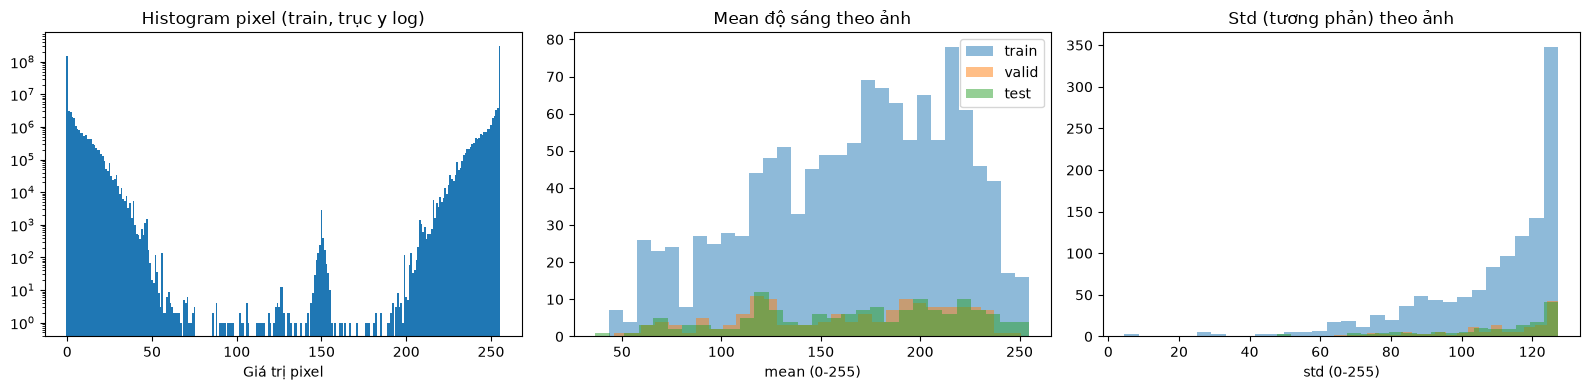

Ảnh ngoại lai (IQR trên mean/std hoặc có kênh màu): 45/1500


,image_key,mean,std,extreme_frac,is_color,severity
1088,train/01_PCB__864.jpg,254.92,4.55,1.0,False,7.19
1079,train/01_PCB__855.jpg,254.88,5.39,1.0,False,7.14
1087,train/01_PCB__863.jpg,254.88,5.48,1.0,False,7.13
1377,test/01_PCB__1253.jpg,254.75,7.91,1.0,False,6.97
200,train/01_PCB__1226.jpg,253.92,16.38,1.0,False,6.42
1380,test/01_PCB__1280.jpg,253.59,18.75,1.0,False,6.27
995,train/01_PCB__756.jpg,252.50,24.87,1.0,False,5.87
19,train/01_PCB__1020.jpg,252.03,27.11,1.0,False,5.73
57,train/01_PCB__1062.jpg,252.02,27.19,1.0,False,5.72
1078,train/01_PCB__854.jpg,251.99,27.37,1.0,False,5.71


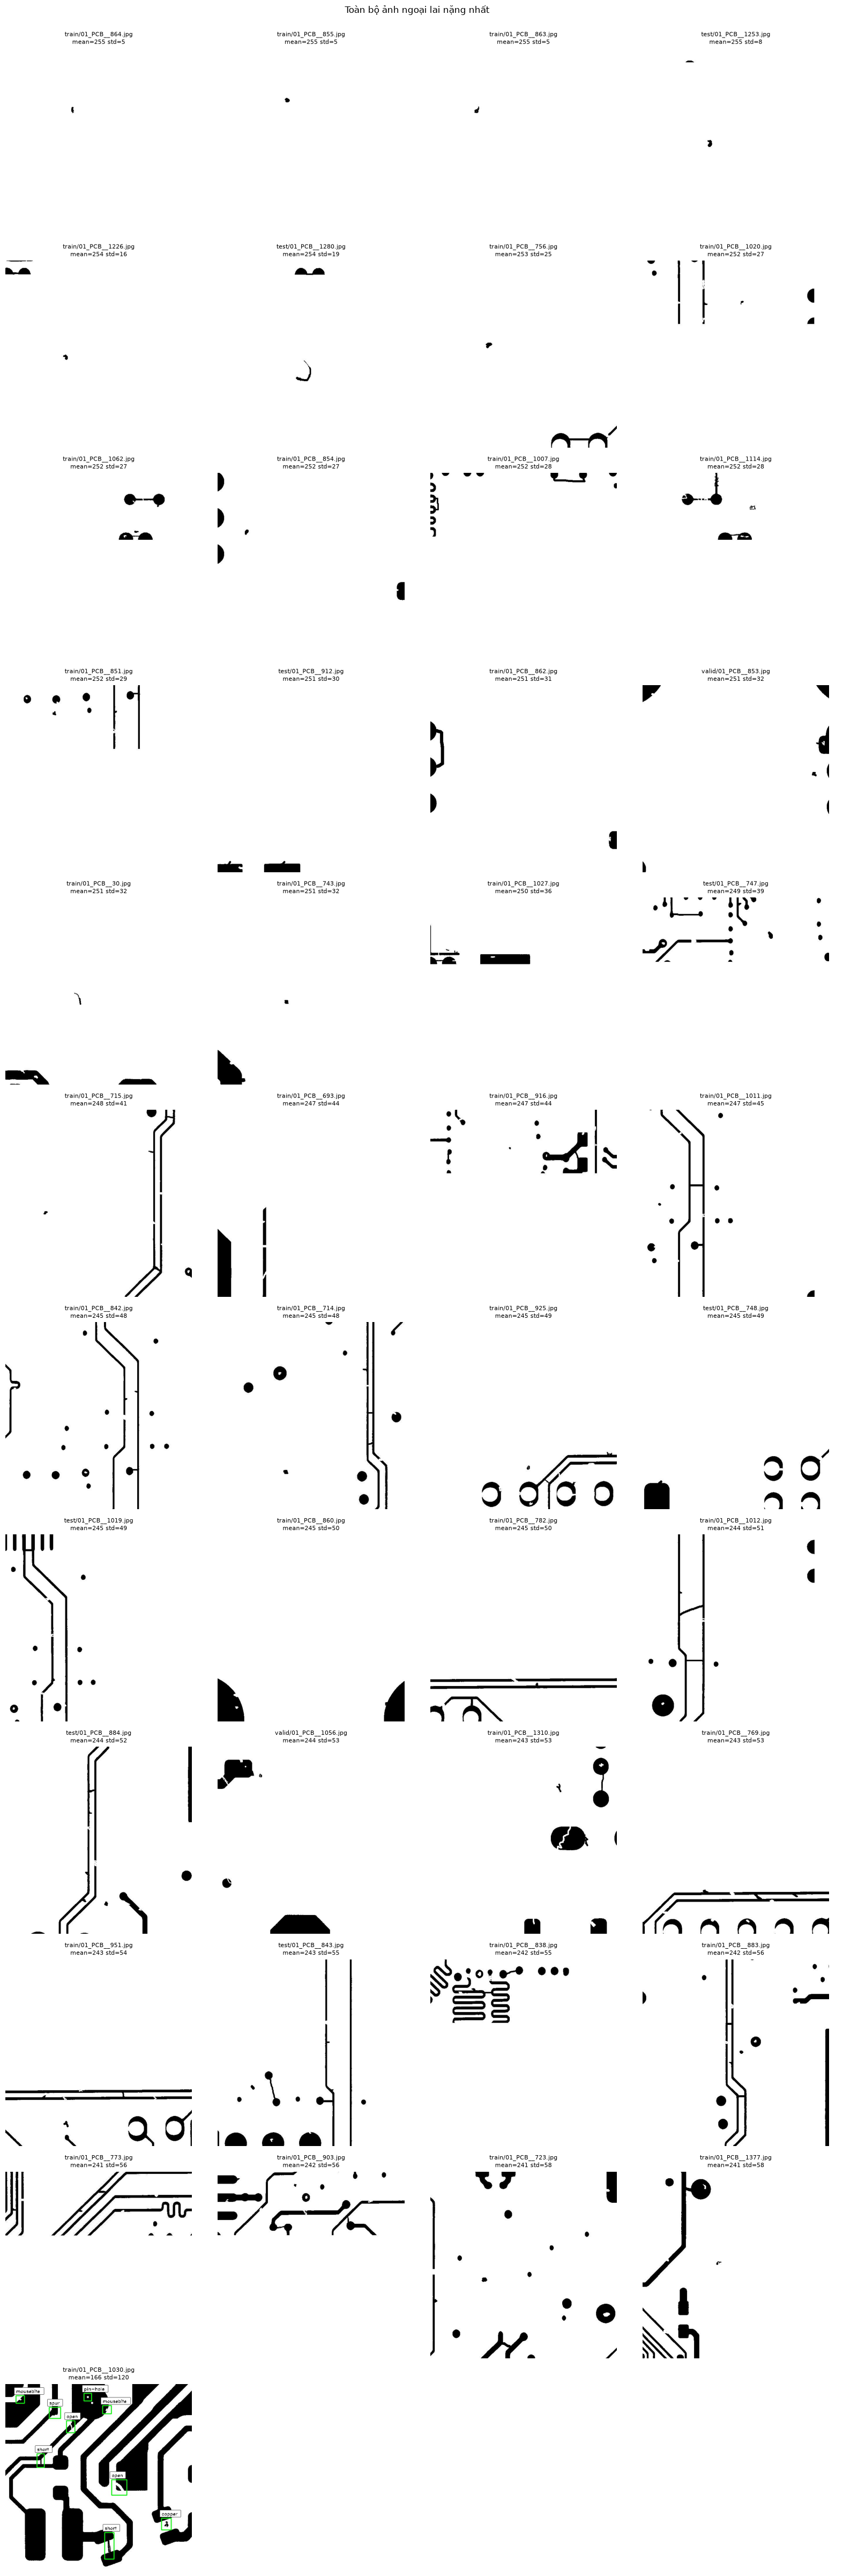

In [28]:
hist_img = np.zeros((len(manifest), 256), dtype=np.int64)
stat_rows = []
for k, row in enumerate(manifest.itertuples()):
    with Image.open(row.image_path) as im:
        rgb = np.asarray(im.convert("RGB"))
    is_color = not (np.array_equal(rgb[..., 0], rgb[..., 1]) and np.array_equal(rgb[..., 1], rgb[..., 2]))
    gray = np.asarray(Image.fromarray(rgb).convert("L")) if is_color else rgb[..., 0]
    hist_img[k] = np.bincount(gray.ravel(), minlength=256)
    stat_rows.append({
        "mean": float(gray.mean()), "std": float(gray.std()),
        "extreme_frac": float(((gray <= 10) | (gray >= 245)).mean()),  # tỷ lệ pixel gần đen/trắng thuần
        "is_color": is_color,
    })
pix = pd.concat([manifest[["split", "image_key"]].reset_index(drop=True), pd.DataFrame(stat_rows)], axis=1)

n_color = int(pix["is_color"].sum())
mode_counts = manifest["mode"].value_counts().to_dict()
print(f"Mode gốc: {mode_counts} | ảnh có kênh màu thật sự khác nhau: {n_color}")
print("Mean / std độ sáng theo ảnh (thang 0-255):")
display(pix.groupby(SPLIT_COL)[["mean", "std", "extreme_frac"]].agg(["mean", "min", "median", "max"])
        .reindex(SPLITS).round(3))

# --- Mean/std pooled chỉ tính trên train (từ histogram) ---
train_hist = hist_img[(manifest[SPLIT_COL] == "train").to_numpy()].sum(axis=0)
values = np.arange(256)
train_mean = (train_hist * values).sum() / train_hist.sum()
train_std = np.sqrt((train_hist * (values - train_mean) ** 2).sum() / train_hist.sum())
extreme_median = float(pix["extreme_frac"].median())
print(f"Train pooled (1 kênh): mean={train_mean:.2f} std={train_std:.2f} "
      f"-> thang 0-1: mean={train_mean / 255:.4f} std={train_std / 255:.4f}")
print(f"Trung vị tỷ lệ pixel <=10 hoặc >=245: {extreme_median:.1%}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(values, train_hist, width=1.0)
axes[0].set(title="Histogram pixel (train, trục y log)", xlabel="Giá trị pixel", yscale="log")
for split in SPLITS:
    sub = pix[pix[SPLIT_COL] == split]
    axes[1].hist(sub["mean"], bins=30, alpha=0.5, label=split)
    axes[2].hist(sub["std"], bins=30, alpha=0.5, label=split)
axes[1].set(title="Mean độ sáng theo ảnh", xlabel="mean (0-255)")
axes[2].set(title="Std (tương phản) theo ảnh", xlabel="std (0-255)")
axes[1].legend()
fig.tight_layout()
plt.show()

# --- Ảnh ngoại lai (luật IQR) ---
def iqr_flag(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)


def robust_z(series):
    med = series.median()
    mad = (series - med).abs().median()
    return (series - med) / (1.4826 * mad + 1e-9)


pix["flag_mean"] = iqr_flag(pix["mean"])
pix["flag_std"] = iqr_flag(pix["std"])
pix["severity"] = np.maximum(robust_z(pix["mean"]).abs(), robust_z(pix["std"]).abs())
outliers = pix[pix["flag_mean"] | pix["flag_std"] | pix["is_color"]].sort_values("severity", ascending=False)
n_outliers = len(outliers)
print(f"Ảnh ngoại lai (IQR trên mean/std hoặc có kênh màu): {n_outliers}/{len(pix)}")
display(outliers[["image_key", "mean", "std", "extreme_frac", "is_color", "severity"]].head(15).round(2))

shown = outliers
if len(shown):
    cols = 4
    rows_n = int(np.ceil(len(shown) / cols))
    fig, axes = plt.subplots(rows_n, cols, figsize=(4 * cols, 4 * rows_n), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, (_, r) in zip(axes.ravel(), shown.iterrows()):
        path = manifest.loc[manifest["image_key"] == r["image_key"], "image_path"].iloc[0]
        with Image.open(path) as im:
            ax.imshow(im.convert("RGB") if r["is_color"] else im.convert("L"), cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"{r['image_key']}\nmean={r['mean']:.0f} std={r['std']:.0f}", fontsize=8)
    fig.suptitle("Toàn bộ ảnh ngoại lai nặng nhất", y=1.0)
    fig.tight_layout()
    plt.show()

- Ảnh gần như nhị phân. 98,7% pixel gần đen hoặc trắng thuần, nên augmentation độ sáng/màu gần như vô nghĩa và nên ưu tiên augmentation hình học
- Chỉ có một ảnh thật sự là RGB là ảnh `train/01_PCB__1030.jpg` 

Phát hiện ra 45 ảnh ngoại lại. Trong đó: 
- 44 ảnh bị xác nhận là ngoại lại do có vùng trắng nền quá lớn
- 1 ảnh trên tập train nhưng có sẵn bounding box và label, ảnh này cũng là ảnh duy nhất mode màu RGB

=> Cần xử lý một ảnh `train/01_PCB__1030.jpg` có khung và chữ nhãn bị in sẵn lên pixel, nên cần loại khỏi train. Các ảnh ngoại lai còn lại là ảnh hợp lệ (box nằm đúng vào chi tiết nhìn thấy), chỉ là do có nhiều nền trắng, nên giữ.

## 5. Xem xét size ảnh và độ chính xác của box

Kiểm tra box vẽ lên có khớp với lỗi nhìn thấy được không: Hai nhóm hình: crop quanh box của từng lớp (xem chi tiết) và ảnh đầy đủ (xem bối cảnh) để xem nhãn đủ tin cậy để train model không

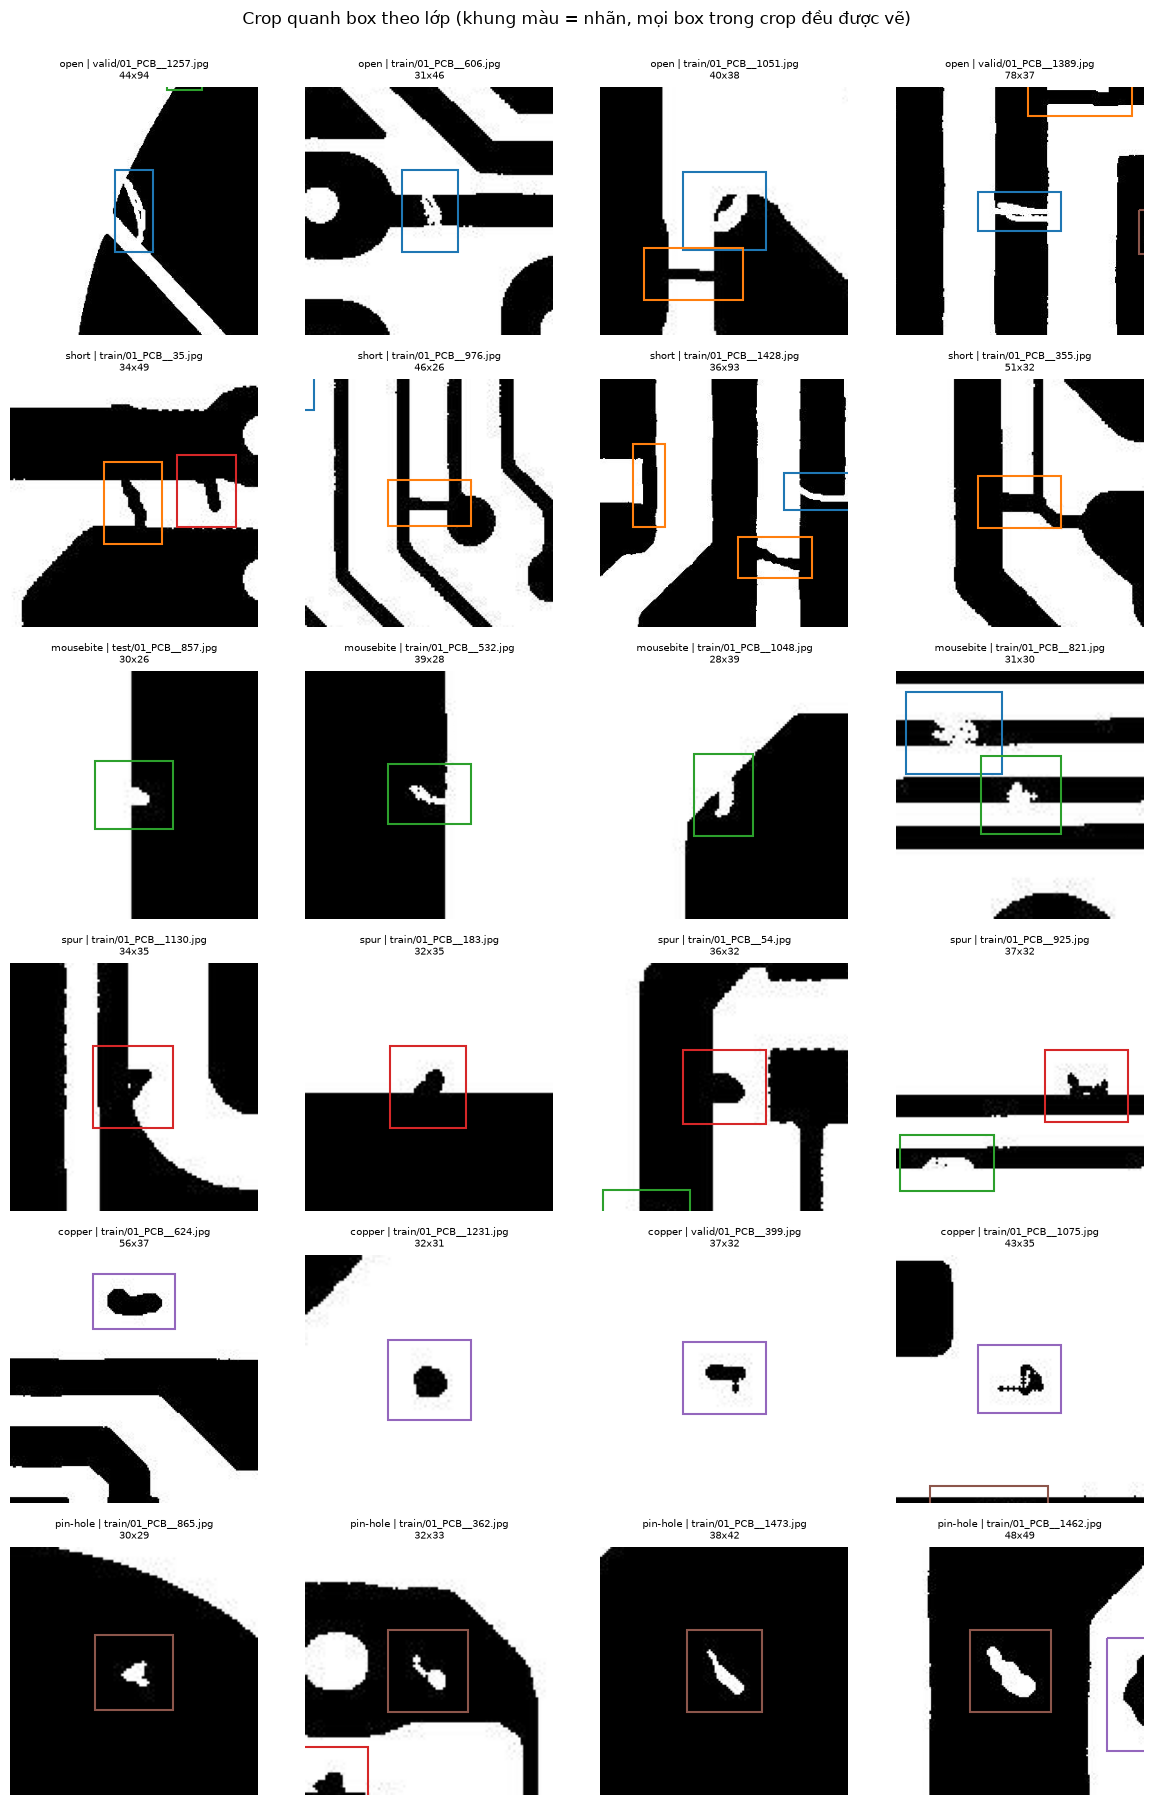

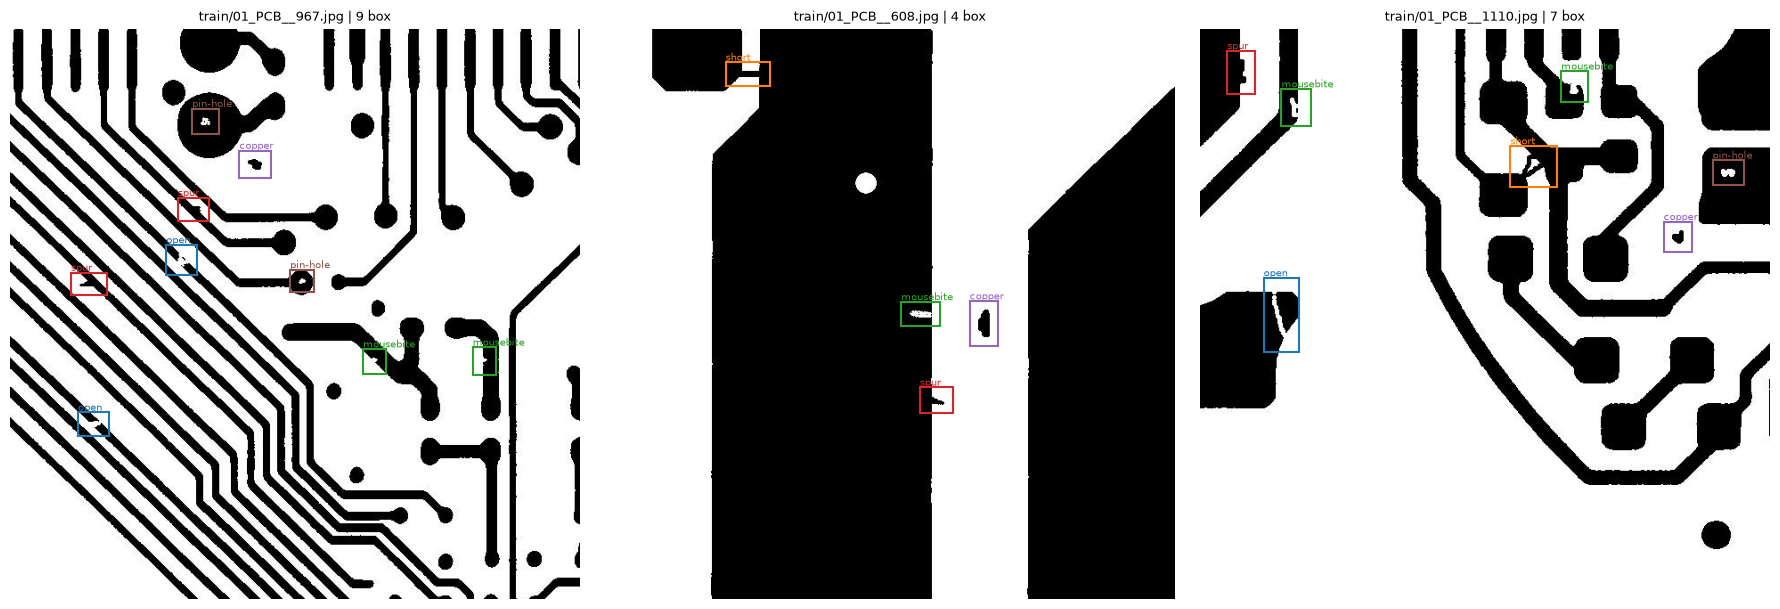

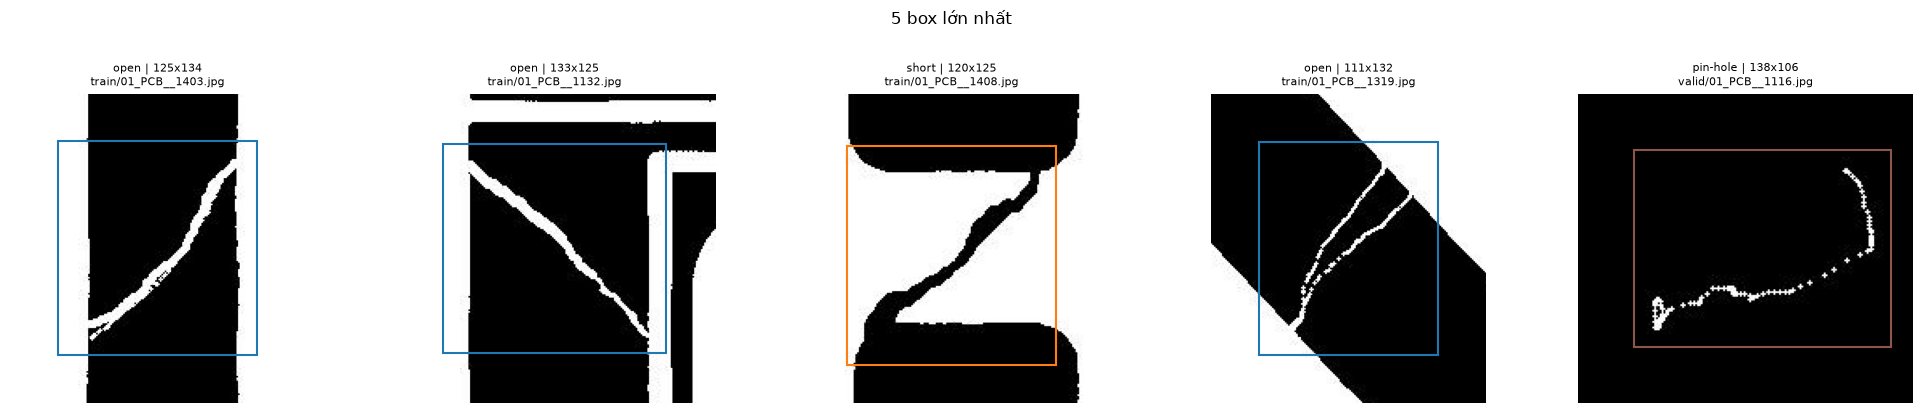

In [24]:
def load_gray(path):
    with Image.open(path) as im:
        return np.asarray(im.convert("L"))


def draw_boxes(ax, boxes, dx=0, dy=0, label=True):
    for b in boxes.itertuples():
        color = colors[b.class_idx]
        ax.add_patch(Rectangle((b.x1 - dx, b.y1 - dy), b.w, b.h, fill=False, edgecolor=color, linewidth=1.5))
        if label:
            ax.text(b.x1 - dx, b.y1 - dy - 2, b.class_name, color=color, fontsize=7)


path_by_key = manifest.set_index("image_key")["image_path"]
PER_CLASS = 4

# --- Crop quanh box, mỗi lớp 4 mẫu ---
fig, axes = plt.subplots(len(CLASS_NAMES), PER_CLASS, figsize=(3 * PER_CLASS, 3 * len(CLASS_NAMES)), squeeze=False)
for r, name in enumerate(CLASS_NAMES):
    sub = annotations[annotations["class_name"] == name]
    picks = sub.sample(n=min(PER_CLASS, len(sub)), random_state=RANDOM_SEED)
    for c in range(PER_CLASS):
        ax = axes[r, c]
        ax.axis("off")
        if c >= len(picks):
            continue
        b = picks.iloc[c]
        img = load_gray(path_by_key[b["image_key"]])
        win = int(max(96, 3 * max(b["w"], b["h"])))
        cx, cy = (b["x1"] + b["x2"]) // 2, (b["y1"] + b["y2"]) // 2
        left = int(np.clip(cx - win // 2, 0, max(0, img.shape[1] - win)))
        top = int(np.clip(cy - win // 2, 0, max(0, img.shape[0] - win)))
        ax.imshow(img[top:top + win, left:left + win], cmap="gray", vmin=0, vmax=255,
                  extent=(0, min(win, img.shape[1] - left), min(win, img.shape[0] - top), 0))
        in_win = annotations[(annotations["image_key"] == b["image_key"])
                             & (annotations["x2"] > left) & (annotations["x1"] < left + win)
                             & (annotations["y2"] > top) & (annotations["y1"] < top + win)]
        draw_boxes(ax, in_win, dx=left, dy=top, label=False)
        ax.set_title(f"{name} | {b['image_key']}\n{int(b['w'])}x{int(b['h'])}", fontsize=7)
fig.suptitle("Crop quanh box theo lớp (khung màu = nhãn, mọi box trong crop đều được vẽ)", y=1.0)
fig.tight_layout()
plt.show()

# --- Ảnh đầy đủ ---
sample_keys = manifest[manifest[SPLIT_COL] == "train"].sample(n=3, random_state=RANDOM_SEED)["image_key"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, key in zip(axes, sample_keys):
    ax.imshow(load_gray(path_by_key[key]), cmap="gray", vmin=0, vmax=255)
    draw_boxes(ax, annotations[annotations["image_key"] == key])
    ax.set_title(f"{key} | {int(manifest.loc[manifest['image_key'] == key, 'n_boxes'].iloc[0])} box", fontsize=9)
    ax.axis("off")
fig.tight_layout()
plt.show()

# --- Xem tay 5 box lớn nhất ---
largest = annotations.nlargest(5, "area")
fig, axes = plt.subplots(1, len(largest), figsize=(4 * len(largest), 4), squeeze=False)
for ax, (_, b) in zip(axes[0], largest.iterrows()):
    img = load_gray(path_by_key[b["image_key"]])
    pad = 30
    l, t = max(0, int(b["x1"]) - pad), max(0, int(b["y1"]) - pad)
    rgt, bot = min(img.shape[1], int(b["x2"]) + pad), min(img.shape[0], int(b["y2"]) + pad)
    ax.imshow(img[t:bot, l:rgt], cmap="gray", vmin=0, vmax=255, extent=(0, rgt - l, bot - t, 0))
    ax.add_patch(Rectangle((b["x1"] - l, b["y1"] - t), b["w"], b["h"], fill=False,
                           edgecolor=colors[int(b["class_idx"])], linewidth=1.5))
    ax.set_title(f"{b['class_name']} | {int(b['w'])}x{int(b['h'])}\n{b['image_key']}", fontsize=8)
    ax.axis("off")
fig.suptitle("5 box lớn nhất", y=1.02)
fig.tight_layout()
plt.show()

- Bounding box có độ lớn nhỏ. Median cạnh box là 34,4 px, p05 là 27,5 px, và 32,0% box nhỏ hơn 32×32 px. -> xem xem crop theo box để model classification học được lỗi tốt hơn
- Box ôm đúng lỗi, không có vấn đề về việc khoanh vùng sai chỗ lỗi

Kiểm tra chất lượng ảnh nếu resize

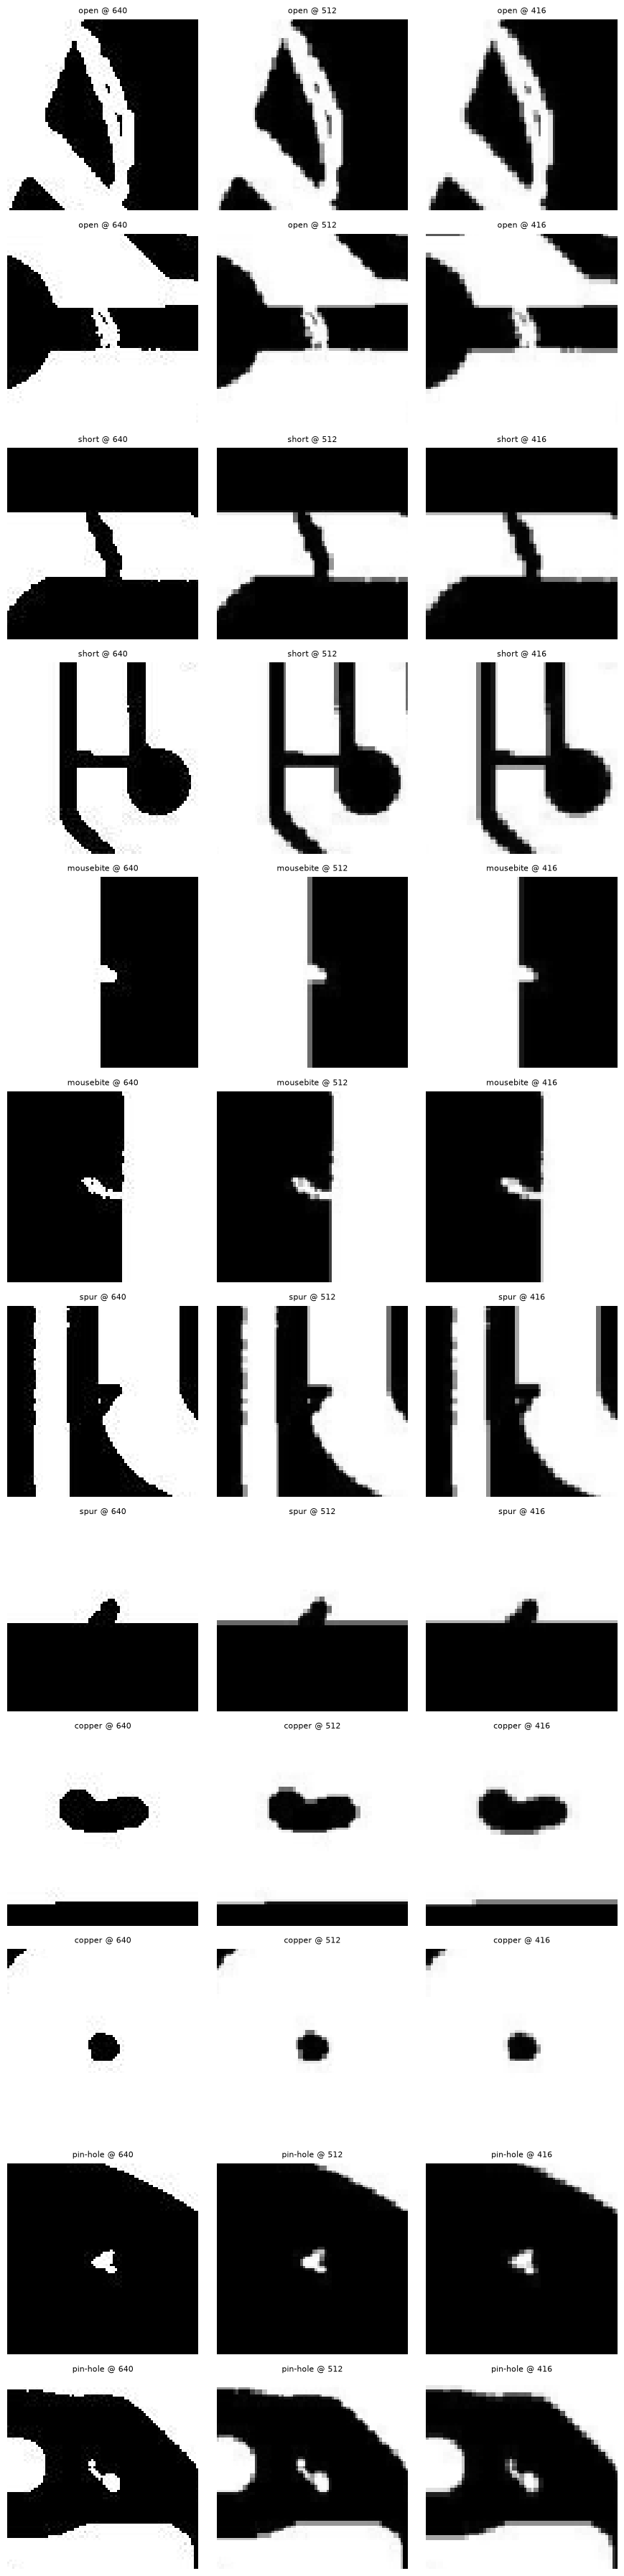

In [41]:
def downscale_roundtrip(img, size):
    small = Image.fromarray(img).resize((size, size), Image.BILINEAR)
    return np.asarray(small.resize((img.shape[1], img.shape[0]), Image.NEAREST))

SIZES = (640, 512, 416)
rows = []
for name in CLASS_NAMES:
    sub = annotations[annotations["class_name"] == name]
    rows.extend(sub.sample(n=2, random_state=RANDOM_SEED).itertuples())

fig, axes = plt.subplots(len(rows), len(SIZES), figsize=(3 * len(SIZES), 3 * len(rows)))
for r, b in enumerate(rows):
    img = load_gray(path_by_key[b.image_key])
    cx, cy = (b.x1 + b.x2) // 2, (b.y1 + b.y2) // 2
    half = 40
    l = int(np.clip(cx - half, 0, img.shape[1] - 2 * half))
    t = int(np.clip(cy - half, 0, img.shape[0] - 2 * half))
    for c, size in enumerate(SIZES):
        view = img if size == 640 else downscale_roundtrip(img, size)
        axes[r, c].imshow(view[t:t + 2 * half, l:l + 2 * half], cmap="gray", vmin=0, vmax=255)
        axes[r, c].set_title(f"{b.class_name} @ {size}", fontsize=8)
        axes[r, c].axis("off")
fig.tight_layout()
plt.show()

- Với YOLO object detection nên giữ input 640 làm mặc định, chỉ hạ xuống khi đã đo recall 

## Kết luận

Kết luận:
- Giữ nguyên cách split, remove ảnh train/01_PCB__1030.jpg
- Với dataset cho YOLO, giữ nguyên size ảnh gốc 640
- Với dataset cho classification,do box có độ lớn nhỏ nên crop các vùng lỗi theo box để model học lỗi tốt hơn và resize ảnh sau crop về 224 
- Khi train model thực hiện augmentation hình học thay vì màu sắc/ độ sáng 

Hạn chế nho nhỏ: Nguồn gốc cách chia split cũng chưa được xác minh. Dữ liệu cũng không có ảnh board sạch nên không đo được false positive